# Computing the transition in the HANC model manually: general equilibrium, non-linear

In [1]:
import numpy as np
import numba as nb
from consav.linear_interp import interp_1d_vec
import matplotlib.pyplot as plt
from consav.grids import equilogspace
from consav.markov import log_rouwenhorst

We continue from `02-Transition-Manually-PE.ipynb`, using the same HANC model with an annual calibration.

## Setup from the partial equilibrium notebook

The household block, the steady state and the partial equilibrium impulse response, as written in `02-Transition-Manually-PE.ipynb`.

In [2]:
class Parameters:
    def __init__(self):
        # preferences
        self.beta = 0.9498866874132476
        self.sigma = 1.0

        # production
        self.alpha = 1/3
        self.delta = 0.1/3
        self.Gamma = 1.0

        # grids
        self.Na = 500
        self.a_min = 0.0
        self.a_max = 10_000.0
        self.a_grid = equilogspace(self.a_min,self.a_max,self.Na)

        # income
        self.rho_z = 0.95
        self.sigma_psi = 0.30*(1.0-self.rho_z**2.0)**0.5
        self.Nz = 7
        self.z_grid, self.z_trans,self.z_ergodic,_,_ = log_rouwenhorst(self.rho_z,self.sigma_psi,self.Nz)


par = Parameters()

### Household steady-state

In [3]:
def solve_hh_backwards_one_step(z_trans, z_grid, a_grid, sigma, beta, r, w, vbeg_a):

    # vbeg_a is the derivative of the value function at the beginning of the period
    Nz, Na = vbeg_a.shape
    a = np.zeros((Nz, Na))
    c = np.zeros((Nz, Na))

    # a. solve step
    for i_z in range(Nz):

        ## i. get c(a',z)
        c_endo = (beta*vbeg_a[i_z])**(-1/sigma)

        # ii. compute m_endo = c(a',z) + a'
        m_endo = c_endo + a_grid # current consumption + end-of-period assets

        # iii. interpolation to fixed grid
        m = (1+r)*a_grid + w*z_grid[i_z] # exogenous grid of coh
        interp_1d_vec(m_endo,a_grid,m,a[i_z]) # fill up the array a[i_z]
        a[i_z,:] = np.fmax(a[i_z,:],0.0) # enforce borrowing constraint
        c[i_z] = m-a[i_z]

    # b. expectation step
    RHS = (1+r)*c**(-sigma)
    vbeg_a_new = z_trans @ RHS

    return c, a, vbeg_a_new


In [4]:
def egm_ss(r, w, par, max_iter = 50_000, tol = 1e-12, verbose = False):
    """ solve the EGM for the steady state """

    # a. initialize
    y = w*par.z_grid
    c = r*par.a_grid[np.newaxis,:] + y[:,np.newaxis]
    Va = (1+r)*c**(-par.sigma)

    # b. iterate
    for it in range(max_iter):

        # i. solve backwards
        c, a, Va_new = solve_hh_backwards_one_step(par.z_trans, par.z_grid, par.a_grid, par.sigma, par.beta, r, w, Va)

        # ii. check convergence
        error = np.max(np.abs(Va - Va_new))
        if verbose:
            print(error)
        if error < tol:
            return c, a, Va_new

        Va = Va_new


### Household forward step

In [5]:
def get_lottery(a, a_grid):
    # step 1: find the i such that a' lies between gridpoints a_i and a_(i+1)
    a_i = np.searchsorted(a_grid, a, side='right') - 1
    a_i = np.clip(a_i, 0, len(a_grid)-2)

    # step 2: implement (8) to obtain lottery probabilities pi
    a_pi = (a_grid[a_i+1] - a)/(a_grid[a_i+1] - a_grid[a_i])

    return a_i, a_pi

@nb.njit
def forward_policy(D, a_i, a_pi):
    Dend = np.zeros_like(D)
    for e in range(a_i.shape[0]):
        for a in range(a_i.shape[1]):
            # send pi(e,a) of the mass to gridpoint i(e,a)
            Dend[e, a_i[e,a]] += a_pi[e,a]*D[e,a]

            # send 1-pi(e,a) of the mass to gridpoint i(e,a)+1
            Dend[e, a_i[e,a]+1] += (1-a_pi[e,a])*D[e,a]

    return Dend

@nb.njit
def forward_iteration(D, z_trans, a_i, a_pi):
    Dend = forward_policy(D, a_i, a_pi)
    return z_trans.T @ Dend

def distribution_ss(a, par, tol=1E-10):
    a_i, a_pi = get_lottery(a, par.a_grid)

    # as initial D, use stationary distribution for s, plus uniform over a
    D = par.z_ergodic[:, np.newaxis] * np.ones_like(par.a_grid) / len(par.a_grid)

    # now iterate until convergence to acceptable threshold
    for _ in range(100_000):
        D_new = forward_iteration(D, par.z_trans, a_i, a_pi)
        if np.max(np.abs(D_new - D)) < tol:
            return D_new
        D = D_new


In [6]:

def household_ss(r, w, par, max_iter = 10_000, tol = 1e-10, verbose = False):
    c, a, Va = egm_ss(r, w, par, max_iter, tol, verbose)
    D = distribution_ss(a, par)
    A = np.sum(D * a)
    C = np.sum(D * c)
    return A, C, D, a, c, Va

In [7]:
def find_ss_beta(beta, par):
    par.beta = beta
    r = 0.05
    w = 1-par.alpha
    K = 4
    A, _, _, _, _, _  = household_ss(r, w, par)
    print(A-K)
    return A-K

from scipy.optimize import brentq
par.beta = brentq(find_ss_beta, 0.9, 0.952, args=(par,))

r_ss = 0.05
Y_ss = 1
K_ss = 4
par.alpha = 1/3
par.Gamma = Y_ss /(K_ss**par.alpha)
par.delta = par.alpha * par.Gamma * K_ss**(par.alpha-1) - r_ss
w_ss = (1-par.alpha) * Y_ss
A_ss, C_ss, D_init, a_ss, c_ss, Va_term = household_ss(r_ss, w_ss, par)

-3.9999999999999987


18.850611300685735
-3.9999999999999964
-3.975423272231022
-3.6903000530831482
-2.7649901969462705
-0.8924823031437121


1.3486783143270866
-0.21484849684405383
0.009982873972194994
-0.0004338327654931362


-8.450455082353869e-07
2.063238468963391e-11
-1.883106115485589e-09


### Household transition block

In [8]:
@nb.njit
def forward_iteration_trans(D_init, z_trans, a_i, a_pi, T):
    Nz, Na = D_init.shape
    D = np.zeros((T, Nz, Na))
    D[0] = D_init
    for t in range(T-1):
        D[t+1] = forward_iteration(D[t], z_trans, a_i[t], a_pi[t])
    return D

In [9]:
def get_impulse_response(Va_term, D_init, r_vec, w_vec, par):
    T = r_vec.size

    # backward step
    a_trans = np.zeros((T, par.Nz, par.Na))
    c_trans = np.zeros((T, par.Nz, par.Na))
    Va_trans = Va_term.copy()
    for t in reversed(range(T)):
        c_trans[t], a_trans[t], Va_trans = solve_hh_backwards_one_step(par.z_trans,
                                                                       par.z_grid,
                                                                       par.a_grid,
                                                                       par.sigma,
                                                                       par.beta,
                                                                       r_vec[t],
                                                                       w_vec[t],
                                                                       Va_trans)

    # forward step
    a_i, a_pi = get_lottery(a_trans, par.a_grid)
    D_trans = forward_iteration_trans(D_init, par.z_trans, a_i, a_pi, T)

    # aggregate
    A_trans = np.sum(D_trans * a_trans, axis = (1,2))
    C_trans = np.sum(D_trans * c_trans, axis = (1,2))

    return C_trans, A_trans, D_trans, c_trans, a_trans

## Transitions in general equilibrium

To solve for the general equilibrium following an exogenous shock, we need to find the sequence of endogenous variables $K$ such that markets clear. 

First, let us define a new `firm` function that returns `r`, `w`, `Y`, and `I`, for a path of `K`. Note that we need to account for the timing of production: $Y_t$ depends on $K_{t-1}$. 

In [10]:
def firm(K, Gamma, K_init, par):
    K_vec = K.copy()
    K_vec[1:] = K[:-1]
    K_vec[0] = K_init # K_vec is a vector of K_{t-1}

    Y = Gamma * K_vec**par.alpha # Y_t uses K_{t-1}
    I = K - (1-par.delta) * K_vec
    r = par.alpha * Y/K_vec - par.delta # r is the interest you receive at t
    w = (1-par.alpha) * Y # w is the wage you receive at t
    return r, w, Y, I

Now, let's simulate a positive TFP shock with persistence $\rho$. For now, assume that $\{K_t\}_{t=0}^T=K_{ss}$. Since $\Gamma_t$ increases over time, $r_t,w_t$ will change over time as well. 

In [11]:
T = 300
K_path = np.ones((T)) * K_ss
Gamma_path = np.ones((T)) * par.Gamma

r, w, Y, I = firm(K_path, Gamma_path, K_ss, par)

In [12]:
r

array([0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05,
       0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.

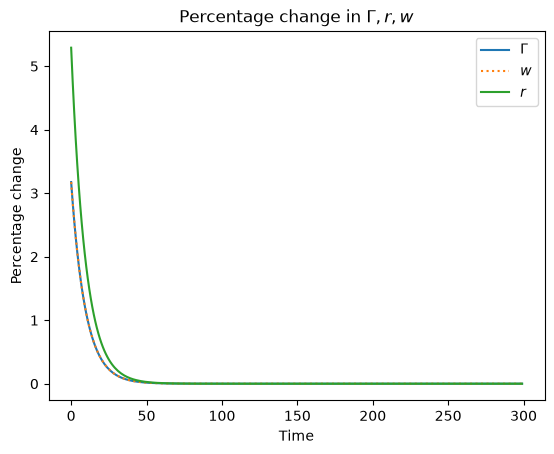

In [13]:
T = 300
sigma = 0.02
rho = 0.9
Gamma_shock = par.Gamma + sigma * rho ** np.arange(T)

K_vec = np.ones((T)) * K_ss
r_vec, w_vec, Y_vec, I_vec = firm(K_vec, Gamma_shock, K_ss, par)

plt.plot((Gamma_shock-par.Gamma)/par.Gamma*100, label = r'$\Gamma$')
plt.plot((w_vec-w_ss)/w_ss*100, label = '$w$', linestyle = ':')
plt.plot((r_vec-r_ss)/r_ss*100, label = '$r$')
plt.title(r"Percentage change in $\Gamma, r, w$")
plt.xlabel("Time")
plt.ylabel("Percentage change")
plt.legend()
plt.show()

We can solve the impulse reponse of households to this path of $\{r_t,w_t\}_{t=0}^T$, and compute market clearing. 

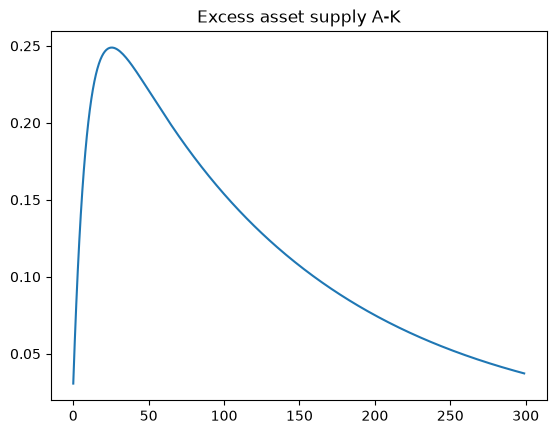

In [14]:
K_trans = np.ones((T)) * K_ss
r_trans, w_trans, Y_trans, I_trans, = firm(K_trans, Gamma_shock, K_ss, par)

C_trans, A_trans, D_trans, c_trans, a_trans = get_impulse_response(Va_term, D_init, r_trans, w_trans, par)
asset_market = A_trans - K_trans
plt.plot(asset_market)
plt.title('Excess asset supply A-K')
plt.show()

The goal is to take this to zero!

### A 'manual Jacobian' approach

To clear the market, we use a quasi-Newton method. 

Recall that, for a function $H(\mathbf{x})$, Newton's method allows us to find $\mathbf{x}$ such that $H(\mathbf{x})=\mathbf{0}$ (note that $H(.)$ returns a vector here) by iterating over this mapping:
$$
\mathbf{x}^{n+1}=\mathbf{x}^n - J(\mathbf{x^n})^{-1} H(\mathbf{x^n}) 
$$
where $J(\mathbf{x})$ is the Jacobian matrix of $H$. 

In our case, $H(.)$ is the market clearing equation, $\mathbf{x}$ is the vector $\{K_t\}_{t=0}^T$, but what is $J$? 

We call $J$ the **sequence-space Jacobian**!

#### Intuitive derivation

First, write the asset market clearing equation as 
$$
\begin{aligned}
H(K_t, \Gamma_t)=A_t^{hh}(\{w_t(K_t,\Gamma_t),r_t(K_t,\Gamma_t)\}_{t=0}^T) - K_t \quad \text{for all }t\in\{0,1,\dots,T-1\}
\end{aligned}
$$
which we can write in vector notation as 
$$
H(\mathbf{K},\mathbf{\Gamma}) = \mathbf{A}^{hh}(\mathbf{w}(\mathbf{K},\mathbf{\Gamma}),\mathbf{r}(\mathbf{K},\mathbf{\Gamma}))-\mathbf{K}
$$

Now, take the derivative with respect to $\mathbf{K}$. This gives us

$$ 
\frac{dH(\mathbf{K},\mathbf{\Gamma})}{d\mathbf{K}} = \frac{d\mathbf{A}}{d\mathbf{w}}\frac{d\mathbf{w}}{d\mathbf{K}}+ \frac{d\mathbf{A}}{d\mathbf{r}}\frac{d\mathbf{r}}{d\mathbf{K}} - \mathbf{I}
$$


The Jacobian with respect to the firms variables are relatively easy to compute, since they only depend on $K_t$ (or $K_{t-1}$ for $r_t$). 

In [15]:
dw_dK_analytical = (1-par.alpha) * par.alpha * par.Gamma * K_ss**(par.alpha-1)
dr_dK_analytical = par.alpha * par.Gamma * (par.alpha-1) * K_ss**(par.alpha-2)

dw_dK = np.zeros((T, T))
dr_dK = np.zeros((T, T))

dw_dK[1:,:-1] = np.eye(T-1) * dw_dK_analytical
dr_dK[1:,:-1] = np.eye(T-1) * dr_dK_analytical

But we need more work for the household Jacobian. Indeed, for every column $s$ of this Jacobian matrix, we need to compute an impulse response following a shock at $s$. This means we need to do $T$ forward and backward step! Let's try it.

In [16]:
T = 300
r_vec = np.ones((T)) * r_ss
w_vec = np.ones((T)) * w_ss

_, A_no_shock, _, _, a_0 = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)
a_ss = a_0[0] # to avoid numerical errors, run a blank transition and update steady state policy functions. This is for numerical precision only, not necessary per se.

In [17]:
h = 1e-4
J_w = np.zeros((T, T))

for s in range(T):
    r_vec = np.ones((T)) * r_ss
    w_vec = np.ones((T)) * w_ss

    w_vec[s] = w_ss + h

    C_trans, A_trans, _, _, _ = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)
    J_w[:,s] = (A_trans - A_no_shock) / h

In [18]:
J_r = np.zeros((T, T))

for s in range(T):
    r_vec = np.ones((T)) * r_ss
    w_vec = np.ones((T)) * w_ss

    r_vec[s] = r_vec[s] + h

    C_trans, A_trans, _, _, _ = get_impulse_response(Va_term, D_init, r_vec, w_vec, par)
    J_r[:,s] = (A_trans - A_no_shock) / h

We can then put things together, using the previously derived formula, to compute the full Jacobian of $H(.)$ with respect to a sequence $\mathbf{K}$.

In [19]:
H_K = J_w @ dw_dK + J_r @ dr_dK - np.eye(T)

Now, let's use this Jacobian and Newton's method to solve for the equilibrium.

In [20]:
K_trans = np.ones((T)) * K_ss
error = 1
tol = 1e-12

while error > tol:
    r_trans, w_trans, Y_trans, I_trans = firm(K_trans, Gamma_shock, K_ss, par)
    C_trans, A_trans, D_trans, c_trans, a_trans = get_impulse_response(Va_term, D_init, r_trans, w_trans, par)
    asset_market = A_trans - K_trans
    error = np.max(np.abs(asset_market))
    print(error)
    K_trans -= np.linalg.solve(H_K, asset_market)

0.24888454666455573
0.0041117421926433195
3.980736018327491e-05
1.2078792721581522e-07


1.045908248897831e-09
7.918110611626616e-12
2.6645352591003757e-14


Done in a few iterations!

Here we kept the Jacobian constant, but we can also do Broyden's method to update the Jacobian

In [21]:
def broyden_jacobian_update(J_prev, x_prev, x_curr, f_prev, f_curr, eps=1e-14):
    """
    Good Broyden update for the Jacobian J.

    J_i = J_{i-1} + ((f_i - f_{i-1}) - J_{i-1}(x_i - x_{i-1}))
                      -----------------------------------------  (x_i - x_{i-1})^T
                           ||x_i - x_{i-1}||_2^2
    """
    s = x_curr - x_prev          # step in x
    y = f_curr - f_prev          # change in residual
    denom = float(s @ s)         # ||s||^2
    if denom <= eps:
        return J_prev            # no update if step is too small
    return J_prev + np.outer((y - J_prev @ s), s) / denom


K = np.ones(T) * K_ss
J = H_K.copy()                   # J_0
tol, max_iter = 1e-14, 200

# initial residual
r,w,Y,I = firm(K, Gamma_shock, K_ss, par)
C,A,D,c,a = get_impulse_response(Va_term, D_init, r, w, par)
F = A - K

for it in range(max_iter):
    err = np.max(np.abs(F))
    print(err)
    if err <= tol:
        break

    # step from current Jacobian
    s = -np.linalg.solve(J, F)
    K_new = K + s

    # new residual
    r,w,Y,I = firm(K_new, Gamma_shock, K_ss, par)
    C,A,D,c,a = get_impulse_response(Va_term, D_init, r, w, par)
    F_new = A - K_new

    # Broyden update (formula above)
    J = broyden_jacobian_update(J, K, K_new, F, F_new)

    K, F = K_new, F_new

0.24888454666455573
0.0041117421926433195
8.439388775727252e-05


3.0162470210370884e-07
9.883951435085692e-10
5.906386491005833e-13


9.769962616701378e-15


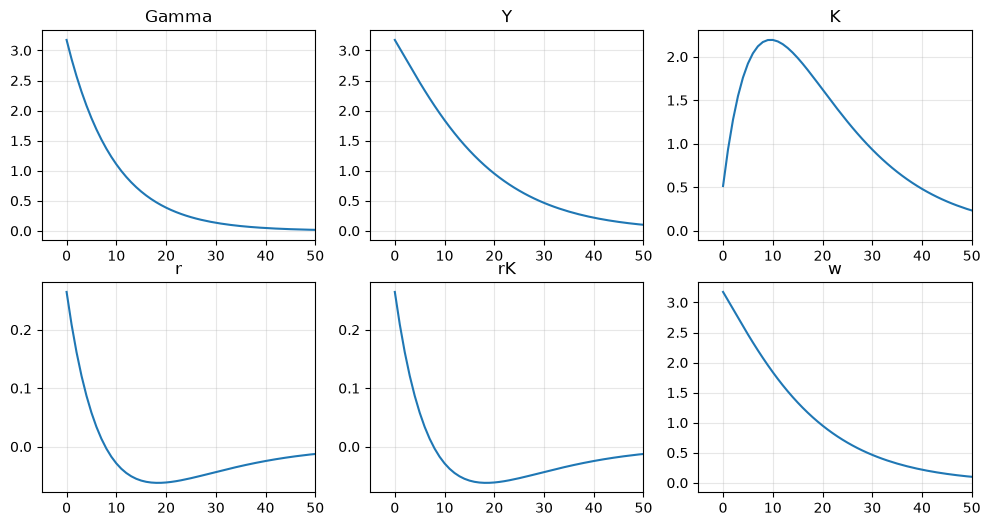

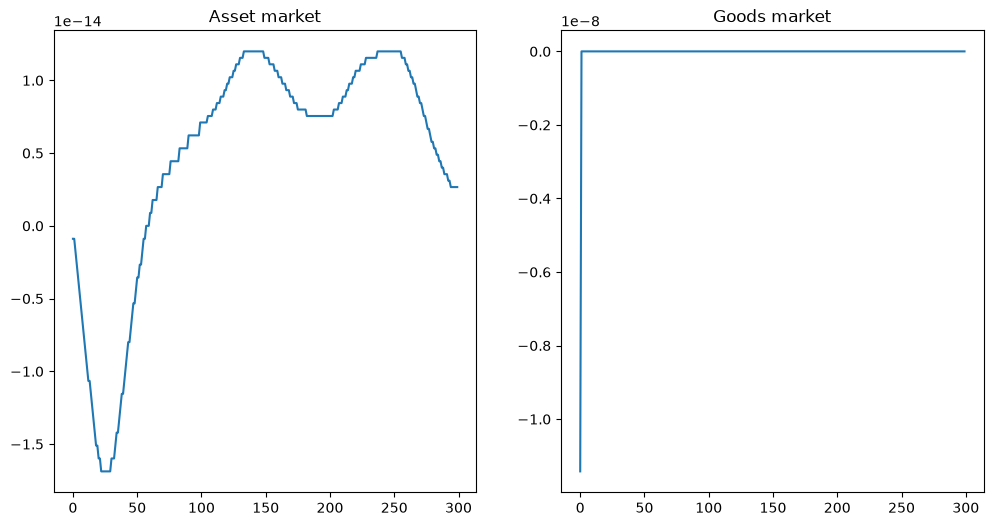

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

axes[0, 0].plot((Gamma_shock-par.Gamma)/par.Gamma * 100)
axes[0, 0].set_title('Gamma')
axes[0, 1].plot((Y_trans-Y_ss)/Y_ss * 100)
axes[0, 1].set_title('Y')
axes[0, 2].plot((K_trans-K_ss)/K_ss * 100)
axes[0, 2].set_title('K')
axes[1, 0].plot((r_trans-r_ss)* 100)
axes[1, 0].set_title('r')
axes[1, 1].plot((r_trans-r_ss)* 100)
axes[1, 1].set_title('rK')
axes[1, 2].plot((w_trans-w_ss) / w_ss* 100)
axes[1, 2].set_title('w')
for ax in axes.flat:
    ax.set_xlim(-5, 50)
    ax.grid(True, alpha =0.3)
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].plot(A_trans-K_trans)
axes[0].set_title('Asset market')
axes[1].plot(Y_trans - C_trans - I_trans)
axes[1].set_title('Goods market')
plt.show()

We can reuse the Jacobian to compute the transitions to a new shock if we want! 

Exercise: compute a GE transition following a (huge) TFP shock with $\sigma=0.1$, and plot your results.

In [23]:
T = 300
sigma = 0.1
rho = 0.9
Gamma_shock = par.Gamma + sigma * rho ** np.arange(T)

# write your code here



































# code

**Solution**

In [24]:
T = 300
sigma = 0.1
rho = 0.9
Gamma_shock = par.Gamma + sigma * rho ** np.arange(T)
# Code here

K_trans_new = np.ones((T)) * K_ss
error = 1
tol = 1e-12

while error > tol:
    r_trans, w_trans, Y_trans, I_trans = firm(K_trans_new, Gamma_shock, K_ss, par)
    C_trans, A_trans, D_trans, c_trans, a_trans = get_impulse_response(Va_term, D_init, r_trans, w_trans, par)
    asset_market = A_trans - K_trans_new
    error = np.max(np.abs(asset_market))
    print(error)
    K_trans_new -= np.linalg.solve(H_K, asset_market)

1.3419310118408436
0.1021078378161615
0.005661596812422509
9.347991465968875e-05
3.1985342880958e-06
1.2544812655335136e-07


1.6137553515704894e-09
9.103384712716434e-11
2.9611868512802175e-12
4.3520742565306136e-14


Solved in one second!

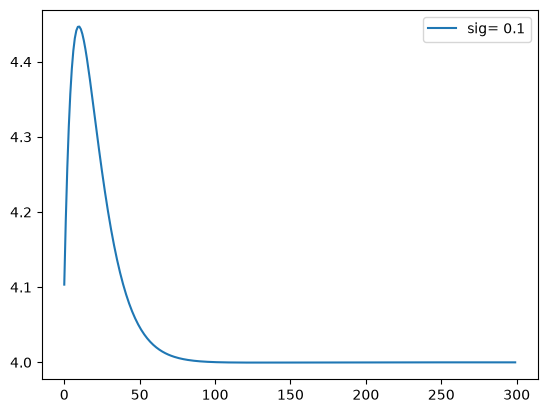

In [25]:
#plt.plot(K_trans, label ='sig= 0.02')
plt.plot(K_trans_new, label ='sig= 0.1')
plt.legend()
plt.show()

### Exercise: transition between two steady states

As at the end of `01-Ramsey.ipynb`, TFP now rises unexpectedly and permanently by 5% in period $t=0$, from $\Gamma_{ss}$ to $1.05\,\Gamma_{ss}$. The economy starts in the old steady state and $\beta$ is kept fixed.

1. Compute the new steady state: find $K$ such that $A^{hh}(r(K),w(K))=K$ with the new $\Gamma$. How much does $r_{ss}$ change? Compare with the Ramsey model. Hint: when bracketing $K$, keep $r<1/\beta-1$, otherwise household assets diverge.
2. Compute the transition path from the old to the new steady state, using the Jacobian `H_K` from the old steady state. What are the initial and terminal conditions?
3. Plot $K_t$, $C_t$, $r_t$ and $w_t$ together with the old and new steady states.

In [ ]:
# write your code here





































# code

**Solution**

The new steady state. We look for the $K$ that clears the asset market, with $r$ and $w$ given by the firm first-order conditions.

In [27]:
Gamma_ss_new = 1.05*par.Gamma

def asset_market_ss(K, Gamma, par):
    r = par.alpha*Gamma*K**(par.alpha-1) - par.delta
    w = (1-par.alpha)*Gamma*K**par.alpha
    A, _, _, _, _, _ = household_ss(r, w, par)
    return A-K

K_ss_new = brentq(asset_market_ss, 1.05*K_ss, 1.2*K_ss, args=(Gamma_ss_new, par))
Y_ss_new = Gamma_ss_new*K_ss_new**par.alpha
r_ss_new = par.alpha*Y_ss_new/K_ss_new - par.delta
w_ss_new = (1-par.alpha)*Y_ss_new
A_ss_new, C_ss_new, _, _, _, Va_term_new = household_ss(r_ss_new, w_ss_new, par)

print(f'K_ss: {K_ss:.4f} -> {K_ss_new:.4f}')
print(f'C_ss: {C_ss:.4f} -> {C_ss_new:.4f}')
print(f'r_ss: {r_ss:.6f} -> {r_ss_new:.6f}')
print(f'w_ss: {w_ss:.4f} -> {w_ss_new:.4f}')

K_ss: 4.0000 -> 4.3037
C_ss: 0.8667 -> 0.9325
r_ss: 0.050000 -> 0.050000
w_ss: 0.6667 -> 0.7173


The interest rate is (almost) unchanged, as in the Ramsey model, but for a different reason. With a zero borrowing limit and income proportional to $w$, the household problem is homogeneous in $w$: if $w$ is scaled by $x$, the policies $c$ and $a'$ are scaled by $x$ too. At the old $r$, the firm conditions scale $K$ and $w$ by the same factor $1.05^{1/(1-\alpha)}$, so $A^{hh}=K$ still holds. The small difference in $r_{ss}$ comes from the asset grid, which is not rescaled.

For the transition, the initial condition is the old steady-state distribution `D_init` with $K_{-1}=K_{ss}$, and the terminal condition is the new steady-state `Va_term_new`.

In [28]:
Gamma_path = np.ones(T)*Gamma_ss_new
K_trans_perm = np.ones(T)*K_ss_new
error = 1

while error > tol:
    r_trans, w_trans, Y_trans, I_trans = firm(K_trans_perm, Gamma_path, K_ss, par)
    C_trans, A_trans, D_trans, c_trans, a_trans = get_impulse_response(Va_term_new, D_init, r_trans, w_trans, par)
    asset_market = A_trans - K_trans_perm
    error = np.max(np.abs(asset_market))
    print(error)
    K_trans_perm -= np.linalg.solve(H_K, asset_market)

0.30159970467501207
0.0028580250343139824
3.4407296812588584e-05
4.3124028081820143e-07
3.889470079343482e-09


1.7924328687968227e-11


4.289901767151605e-13


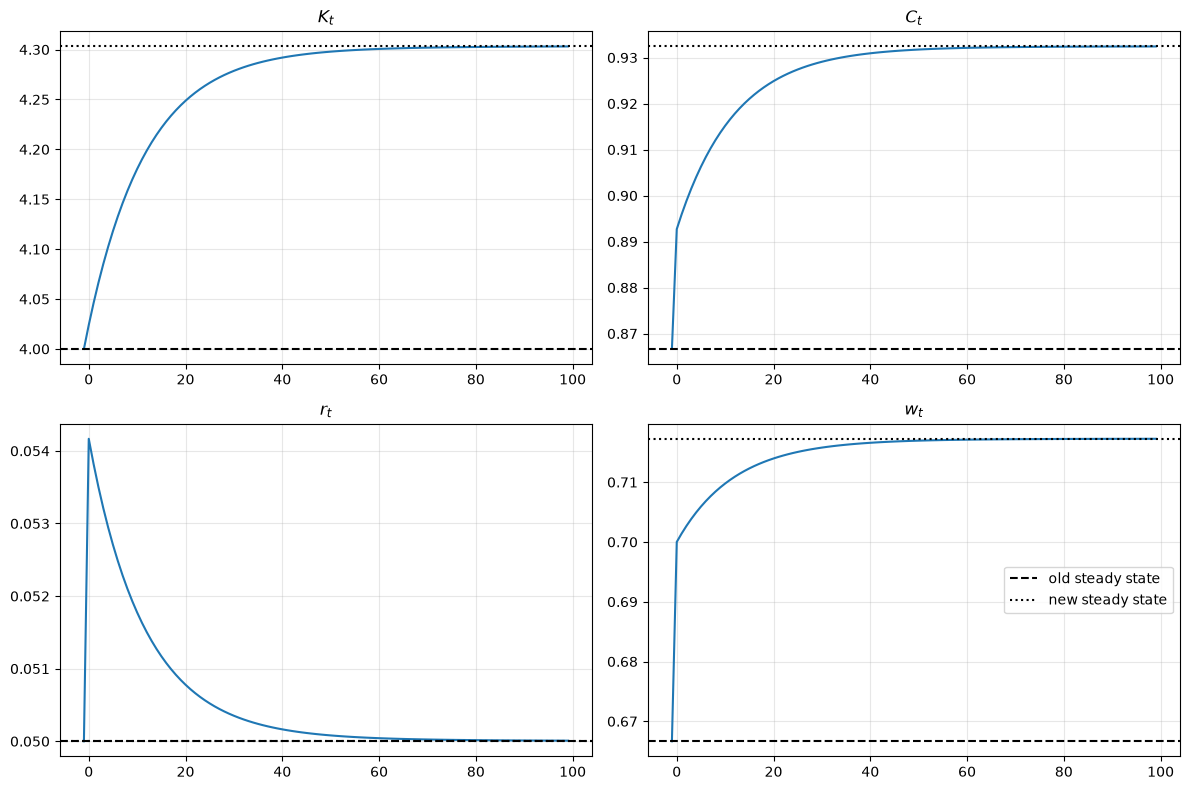

In [29]:
T_plot = 100
paths = [('$K_t$', K_trans_perm, K_ss, K_ss_new),
         ('$C_t$', C_trans, C_ss, C_ss_new),
         ('$r_t$', r_trans, r_ss, r_ss_new),
         ('$w_t$', w_trans, w_ss, w_ss_new)]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (title, path, old_ss, new_ss) in zip(axes.flat, paths):
    ax.plot(np.arange(-1, T_plot), np.insert(path[:T_plot], 0, old_ss))
    ax.axhline(old_ss, ls='--', color='black', label='old steady state')
    ax.axhline(new_ss, ls=':', color='black', label='new steady state')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[1, 1].legend()
fig.tight_layout()
plt.show()